# Análisis inicial **Default of Credit Card Clients**

## Objetivos 

1. Cargar y explorar la base de datos.
2. Identificar la variable objetivo de incumplimiento.
3. Revisar dimensiones, tipos de variables y valores faltantes.
4. Obtener estadísticas descriptivas básicas.
5. Calcular la tasa global de incumplimiento.
6. Explorar cómo cambia el incumplimiento según algunas variables importantes.

## Contexto

Este conjunto de datos contiene información de clientes de tarjetas de crédito y una variable objetivo que indica si hubo incumplimiento de pago en el siguiente mes.

La meta general del proyecto será construir modelos que permitan estimar la probabilidad de incumplimiento a partir de variables demográficas, financieras e históricas de pago.

Dataset: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
f = "../data/default of credit card clients.xls" # Cambia esto por la ruta correcta a tu archivo

df = pd.read_excel(f, header=1) # El header=1 indica que la primera fila (índice 0) es el encabezado, y la segunda fila (índice 1) contiene los nombres de las columnas.
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [3]:
print("Dimensiones del dataset:", df.shape)
df.columns # Muestra los nombres de las columnas

Dimensiones del dataset: (30000, 25)


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

#### Información de las variables

- **ID:** Identificador único del cliente.

- **LIMIT_BAL:** Monto del crédito otorgado (dólares taiwaneses); incluye tanto el crédito al consumo individual como el crédito familiar (complementario).

- **SEX:** Sexo  
  - `1 = masculino`
  - `2 = femenino`

- **EDUCATION:** Educación  
  - `1 = estudios de posgrado`
  - `2 = universitarios`
  - `3 = bachillerato`
  - `4 = otros`

- **MARRIAGE:** Estado civil  
  - `1 = casado`
  - `2 = soltero`
  - `3 = otros`

- **AGE:** Edad (en años).

- **PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6:** Historial de pagos anteriores.  
  Se realizó un seguimiento de los registros de pagos mensuales anteriores (de abril a septiembre de 2005) de la siguiente manera:
  - **PAY_0:** estado de pago en septiembre de 2005
  - **PAY_2:** estado de pago en agosto de 2005
  - **PAY_3:** estado de pago en julio de 2005
  - **PAY_4:** estado de pago en junio de 2005
  - **PAY_5:** estado de pago en mayo de 2005
  - **PAY_6:** estado de pago en abril de 2005

  La escala de medición para el estado de pago es:
  - `-1 = pago puntual`
  - `1 = retraso en el pago de un mes`
  - `2 = retraso en el pago de dos meses`
  - `...`
  - `8 = retraso en el pago de ocho meses`
  - `9 = retraso en el pago de nueve meses o más`

- **BILL_AMT1, BILL_AMT2, BILL_AMT3, BILL_AMT4, BILL_AMT5, BILL_AMT6:** Importe del extracto de factura (dólares taiwaneses).  
  - **BILL_AMT1:** importe del extracto de factura de septiembre de 2005
  - **BILL_AMT2:** importe del extracto de factura de agosto de 2005
  - **BILL_AMT3:** importe del extracto de factura de julio de 2005
  - **BILL_AMT4:** importe del extracto de factura de junio de 2005
  - **BILL_AMT5:** importe del extracto de factura de mayo de 2005
  - **BILL_AMT6:** importe del extracto de factura de abril de 2005

- **PAY_AMT1, PAY_AMT2, PAY_AMT3, PAY_AMT4, PAY_AMT5, PAY_AMT6:** Importe del pago anterior (dólares taiwaneses).  
  - **PAY_AMT1:** importe pagado en septiembre de 2005
  - **PAY_AMT2:** importe pagado en agosto de 2005
  - **PAY_AMT3:** importe pagado en julio de 2005
  - **PAY_AMT4:** importe pagado en junio de 2005
  - **PAY_AMT5:** importe pagado en mayo de 2005
  - **PAY_AMT6:** importe pagado en abril de 2005

- **default payment next month:** Variable objetivo que indica si el cliente incurrió en incumplimiento de pago en el siguiente mes.  
  - `1 = sí hubo incumplimiento`
  - `0 = no hubo incumplimiento`

In [4]:
df = df.rename(columns={
"default payment next month": "default_next_month"
}) # Renombramos la columna  default payment next month a default_next_month

In [5]:
df.columns # Verificamos que el cambio se haya realizado correctamente

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default_next_month'],
      dtype='str')

In [6]:
df.info() # Información general del dataset, incluyendo tipos de datos y valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  30000 non-null  int64
 1   LIMIT_BAL           30000 non-null  int64
 2   SEX                 30000 non-null  int64
 3   EDUCATION           30000 non-null  int64
 4   MARRIAGE            30000 non-null  int64
 5   AGE                 30000 non-null  int64
 6   PAY_0               30000 non-null  int64
 7   PAY_2               30000 non-null  int64
 8   PAY_3               30000 non-null  int64
 9   PAY_4               30000 non-null  int64
 10  PAY_5               30000 non-null  int64
 11  PAY_6               30000 non-null  int64
 12  BILL_AMT1           30000 non-null  int64
 13  BILL_AMT2           30000 non-null  int64
 14  BILL_AMT3           30000 non-null  int64
 15  BILL_AMT4           30000 non-null  int64
 16  BILL_AMT5           30000 non-null  int64
 17  BILL

In [7]:
missing = df.isna().sum().to_frame("missing_count") # Contamos el número de valores nulos en cada columna y lo convertimos a un DataFrame
# .isna() devuelve un DataFrame booleano donde True indica valores nulos
# sum() cuenta el número de True en cada columna
# to_frame() convierte la Serie resultante en un DataFrame con el nombre de la columna "missing_count".
missing["missing_pct"] = 100 * missing["missing_count"] / len(df) # Calculamos el porcentaje de valores nulos en cada columna
missing.sort_values("missing_count", ascending=False)
# Mostramos las columnas con valores nulos, ordenadas por la cantidad de valores nulos

,missing_count,missing_pct
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


In [8]:
df.describe().T # Estadísticas descriptivas de las columnas numéricas, transpuestas para mejor visualización

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


### Variable objetivo

La variable **`default payment next month`** es la **variable objetivo** del problema.  Indica si el cliente **incumplió** o **no incumplió** con el pago en el mes siguiente al periodo de observación.

Su codificación es:

- `1 = sí hubo incumplimiento`
- `0 = no hubo incumplimiento`

En otras palabras, esta variable responde a la pregunta: **¿El cliente cayó en incumplimiento en el siguiente mes?**


#### Importancia en el proyecto

Esta variable será la que se intentará **predecir** usando el resto de las variables del dataset.  
Por ello, el problema se plantea como un problema de **clasificación binaria**, donde el objetivo es estimar la probabilidad de que:

$$
P(\text{default payment next month} = 1 \mid X)
$$

donde $X$ representa las características del cliente.

In [9]:
df["default_next_month"].value_counts() # Contamos la cantidad de casos en cada clase de la variable objetivo

default_next_month
0    23364
1     6636
Name: count, dtype: int64

In [10]:
# La tasa de incumplimiento se calcula como el promedio de la variable binaria, ya que 1 representa incumplimiento y 0 representa cumplimiento.
default_rate = df["default_next_month"].mean() 
# default_rate se multiplica por 100 para convertirlo a porcentaje y se formatea a dos decimales.
print(f"Tasa global de incumplimiento: {100 * default_rate:.2f}%")

Tasa global de incumplimiento: 22.12%


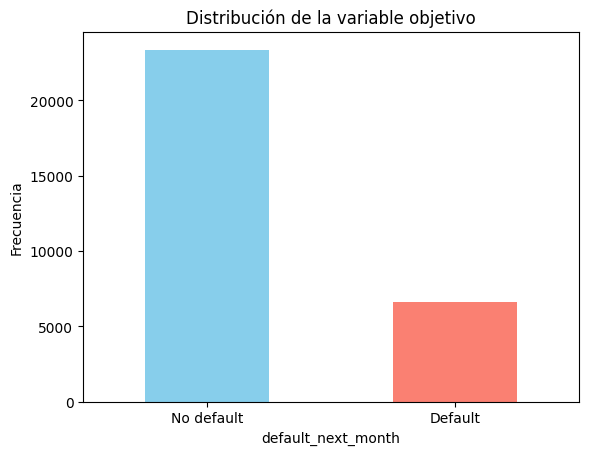

In [11]:
# Graficamos la distribución de la variable objetivo como un gráfico de barras 
df["default_next_month"].value_counts().sort_index().plot(kind="bar", color=["skyblue", "salmon"]) 
# .value_counts() cuenta la cantidad de casos en cada clase de la variable objetivo
# .sort_index() ordena los resultados por el índice (en este caso, las clases de la variable objetivo)
plt.xticks([0, 1], ["No default", "Default"], rotation=0) # Etiquetas para las clases en el eje x, con rotación de 0 grados para que estén horizontales
plt.ylabel("Frecuencia") # Etiqueta del eje y
plt.title("Distribución de la variable objetivo") # Título del gráfico
plt.show()

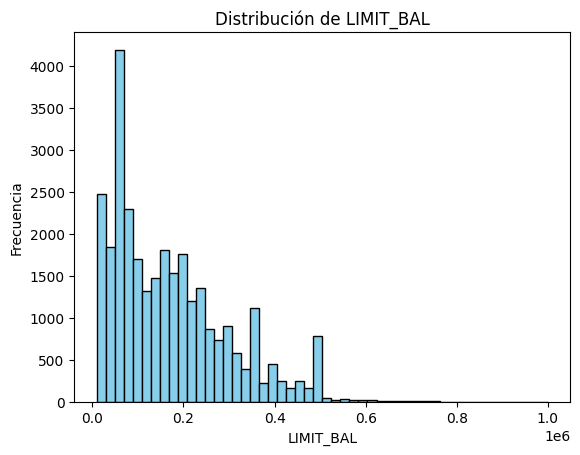

In [12]:
# Distribución del límite de crédito
df["LIMIT_BAL"].plot(kind="hist", # Histograma para visualizar la distribución de la variable LIMIT_BAL
bins=50, # Número de barras en el histograma
edgecolor='black', # Color del borde de las barras para mejor visualización
color='skyblue') # Color de las barras del histograma
plt.xlabel("LIMIT_BAL") # Etiqueta del eje x
plt.ylabel("Frecuencia") # Etiqueta del eje y
plt.title("Distribución de LIMIT_BAL") # Título del gráfico
plt.show()

In [13]:
df["LIMIT_BAL"].describe() # Estadísticas descriptivas de la variable LIMIT_BAL

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

## Tasa de incumplimiento por sexo

Si $Y \in \{0,1\}$ es una variable binaria, entonces su media muestral satisface

$$
\bar{Y}=\frac{1}{n}\sum_{i=1}^n Y_i
=\frac{\#\{i:Y_i=1\}}{n},
$$

por lo que coincide con la proporción de observaciones con valor 1. En este problema, esa proporción representa la tasa de incumplimiento.

In [14]:
default_by_sex = df.groupby("SEX")["default_next_month"].agg(["mean", "count"])
# .groupby("SEX") agrupa el DataFrame por la variable
# ["default_next_month"] selecciona la columna de interés para el cálculo
# .agg(["mean", "count"]) calcula el promedio (tasa de incumplimiento) y el conteo de casos para cada grupo de sexo
default_by_sex["mean_pct"] = 100 * default_by_sex["mean"]
default_by_sex

,mean,count,mean_pct
SEX,,,
1,0.241672,11888,24.167227
2,0.207763,18112,20.776281


se observa lo siguiente:

- Entre los **hombres**, la tasa de incumplimiento es de **24.17\%**.
- Entre las **mujeres**, la tasa de incumplimiento es de **20.78\%**.

Por lo tanto, en este conjunto de datos, los clientes masculinos presentan una tasa de incumplimiento mayor que las clientes femeninas, con una diferencia aproximada de

$$
24.17\% - 20.78\% = 3.39 \text{ puntos porcentuales.}
$$

Además, el número de observaciones es considerable en ambos grupos:

- **11,888** hombres
- **18,112** mujeres

lo que da cierta estabilidad descriptiva a esta comparación inicial.

Sin embargo, esta diferencia no debe interpretarse todavía como una relación causal, ya que puede estar asociada también con otras variables del conjunto de datos, como el límite de crédito, la edad, el nivel educativo o, especialmente, el historial previo de pagos. Por ello, más adelante será importante complementar este análisis descriptivo con modelos multivariados.


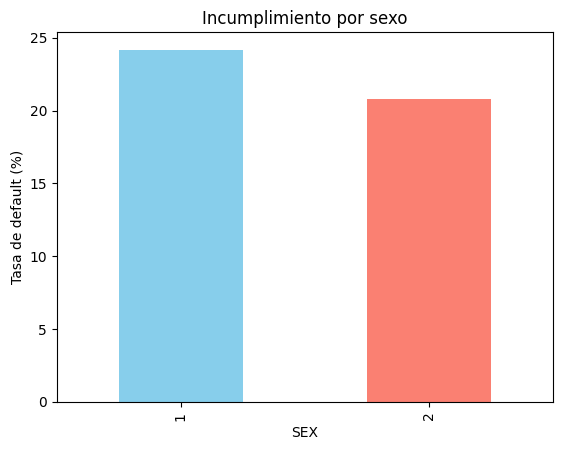

In [15]:
(100 * df.groupby("SEX")["default_next_month"].mean()).plot(kind="bar", color=["skyblue", "salmon"])
plt.ylabel("Tasa de default (%)")
plt.title("Incumplimiento por sexo")
plt.show()

In [16]:
# Tasa de incumplimiento por nivel educativo
default_by_edu = df.groupby("EDUCATION")["default_next_month"].agg(["mean", "count"])
# groupby("EDUCATION") agrupa el DataFrame por la variable EDUCATION
# ["default_next_month"] selecciona la columna de interés para el cálculo
# .agg(["mean", "count"]) calcula el promedio (tasa de incumplimiento) y el conteo de casos para cada grupo de nivel educativo
default_by_edu["mean_pct"] = 100 * default_by_edu["mean"]
print(default_by_edu.sort_index()) # Mostramos la tasa de incumplimiento por nivel educativo, ordenada por el índice (nivel educativo)

               mean  count   mean_pct
EDUCATION                            
0          0.000000     14   0.000000
1          0.192348  10585  19.234766
2          0.237349  14030  23.734854
3          0.251576   4917  25.157616
4          0.056911    123   5.691057
5          0.064286    280   6.428571
6          0.156863     51  15.686275


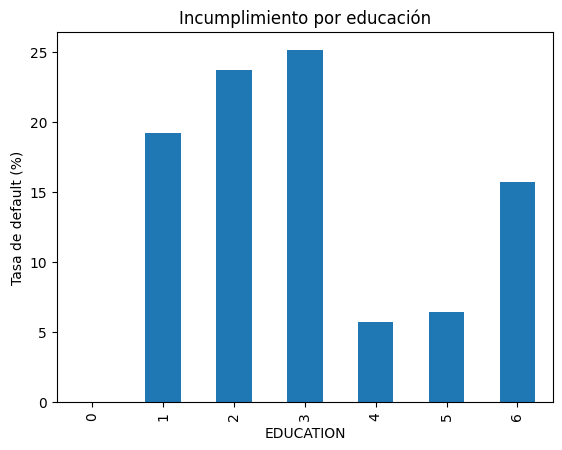

In [17]:
(100 * df.groupby("EDUCATION")["default_next_month"].mean()).sort_index().plot(kind="bar")
plt.ylabel("Tasa de default (%)")
plt.title("Incumplimiento por educación")
plt.show()

- Los clientes con **estudios de posgrado** (`1`) presentan una tasa de incumplimiento de **19.23\%**.
- Los clientes con **estudios universitarios** (`2`) presentan una tasa de **23.73\%**.
- Los clientes con **bachillerato** (`3`) presentan la tasa más alta entre las categorías principales, con **25.16\%**.

Esto sugiere, de manera descriptiva, que dentro de las categorías educativas más numerosas existe un patrón en el que el incumplimiento es menor en clientes con mayor nivel educativo y mayor en clientes con menor nivel educativo.

Sin embargo, también aparecen categorías `0`, `5` y `6`, que no forman parte de la codificación principal esperada. Estas categorías probablemente corresponden a **valores atípicos, errores de captura o categorías no documentadas**. Además, sus tamaños muestrales son muy pequeños:

- `0`: 14 observaciones
- `5`: 280 observaciones
- `6`: 51 observaciones

Por esa razón, sus tasas de incumplimiento deben interpretarse con mucha cautela, ya que pueden ser inestables y no comparables directamente con las categorías principales.


In [18]:
# Tasa de incumplimiento por estado civil
default_by_marriage = df.groupby("MARRIAGE")["default_next_month"].agg(["mean", "count"])
# groupby("MARRIAGE") agrupa el DataFrame por la variable MARRIAGE
# ["default_next_month"] selecciona la columna de interés para el cálculo
# .agg(["mean", "count"]) calcula el promedio (tasa de incumplimiento) y el conteo de casos para cada grupo de estado civil
default_by_marriage["mean_pct"] = 100 * default_by_marriage["mean"]
print(default_by_marriage.sort_index()) # Mostramos la tasa de incumplimiento por estado civil, ordenada por el índice (estado civil)


              mean  count   mean_pct
MARRIAGE                            
0         0.092593     54   9.259259
1         0.234717  13659  23.471704
2         0.209283  15964  20.928339
3         0.260062    323  26.006192


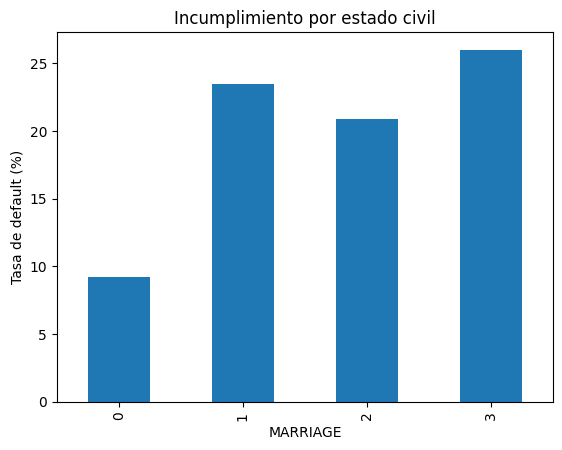

In [19]:
(100 * df.groupby("MARRIAGE")["default_next_month"].mean()).sort_index().plot(kind="bar")
plt.ylabel("Tasa de default (%)")
plt.title("Incumplimiento por estado civil")
plt.show()

En la variable `MARRIAGE`, los clientes **casados** (`1`) presentan una tasa de incumplimiento de **23.47%**, mientras que los **solteros** (`2`) muestran una tasa ligeramente menor, de **20.93%**. La categoría `3` (**otros**) tiene la tasa más alta, con **26.01%**, aunque su tamaño muestral es muy pequeño (**323** casos), por lo que debe interpretarse con cautela. Asimismo, la categoría `0` registra una tasa de **9.26%**, pero sólo contiene **54** observaciones y probablemente corresponde a una codificación atípica o no documentada. En conjunto, la comparación sugiere diferencias descriptivas por estado civil, aunque será necesario depurar las categorías no estándar antes de un análisis más formal.

In [20]:
# Tasa de incumplimiento por grupos de edad
bins = [20, 30, 40, 50, 60, 80] # Definimos los límites de los grupos de edad. El último límite (80) es un valor arbitrario que cubre edades mayores a 60.
labels = ["20-29", "30-39", "40-49", "50-59", "60+"] # Definimos las etiquetas para cada grupo de edad

df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)
df[["AGE", "AGE_GROUP"]].head()

,AGE,AGE_GROUP
0,24,20-29
1,26,20-29
2,34,30-39
3,37,30-39
4,57,50-59


In [23]:
default_by_age_group = df.groupby("AGE_GROUP", observed=False)["default_next_month"].agg(["mean", "count"])
# groupby("AGE_GROUP") agrupa el DataFrame por la variable AGE_GROUP
# observed=False asegura que se incluyan todos los grupos de edad definidos en las etiquetas, incluso si no hay datos para algunos grupos
# ["default_next_month"] selecciona la columna de interés para el cálculo
# .agg(["mean", "count"]) calcula el promedio (tasa de incumplimiento) y el conteo de casos para cada grupo de edad
default_by_age_group["mean_pct"] = 100 * default_by_age_group["mean"]
print(default_by_age_group)

               mean  count   mean_pct
AGE_GROUP                            
20-29      0.228426   9618  22.842587
30-39      0.202527  11238  20.252714
40-49      0.229734   6464  22.973391
50-59      0.248612   2341  24.861170
60+        0.283186    339  28.318584


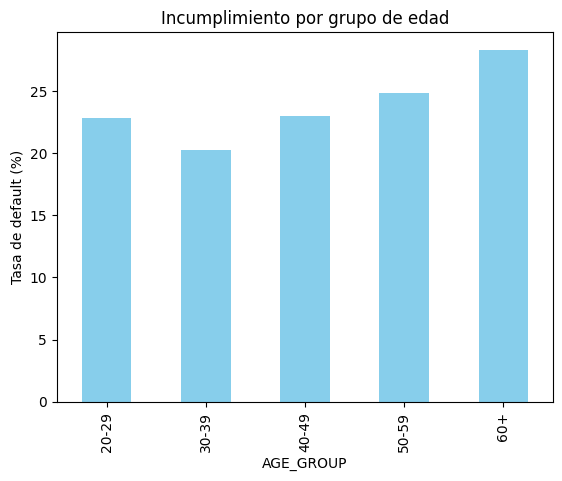

In [28]:
(100 * df.groupby("AGE_GROUP", observed=False)["default_next_month"].mean()).plot(kind="bar", color="skyblue")
plt.ylabel("Tasa de default (%)")
plt.title("Incumplimiento por grupo de edad")
plt.show()

La tasa de incumplimiento por grupos de edad muestra que el riesgo no es uniforme entre rangos etarios. El grupo de **30 a 39 años** presenta la tasa más baja, con **20.25%**, mientras que el incumplimiento aumenta en los grupos de mayor edad: **22.84%** en 20–29 años, **22.97%** en 40–49 años, **24.86%** en 50–59 años y **28.32%** en 60 años o más. Aunque el último grupo tiene pocas observaciones (**339**), el patrón general sugiere descriptivamente que el incumplimiento tiende a ser más alto en edades mayores, especialmente a partir de los 50 años.

### Historial de pagos

Las variables `PAY_0`, `PAY_2`, ..., `PAY_6` reflejan el estatus de pago en meses previos.
Estas variables probablemente serán muy relevantes para predecir incumplimiento.

In [24]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df[pay_cols].describe().T # Estadísticas descriptivas de las columnas de historial de pagos, transpuestas para mejor visualización

,count,mean,std,min,25%,50%,75%,max
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.0,0.0,0.0,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.0,0.0,0.0,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.0,0.0,0.0,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.0,0.0,0.0,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.0,0.0,0.0,8.0
PAY_6,30000.0,-0.291100,1.149988,-2.0,-1.0,0.0,0.0,8.0


In [25]:
for col in pay_cols:
    print(f"\nDistribución de {col}")
    print(df[col].value_counts().sort_index())


Distribución de PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Distribución de PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Distribución de PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

Distribución de PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

Distribución de PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

Distribución de PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766


La distribución de las variables `PAY_0` a `PAY_6` muestra que la mayoría de los clientes se concentra en las categorías **-1** y **0**, así como en algunos casos en **-2**, lo que indica que predominan estados de pago puntuales o sin retrasos severos. Sin embargo, también aparecen clientes con retrasos de **1, 2, 3 o más meses**, aunque con frecuencias mucho menores. En general, conforme aumenta el nivel de atraso, el número de observaciones disminuye de manera importante, lo que sugiere que los retrasos severos son menos comunes, pero potencialmente más informativos para predecir incumplimiento futuro.

### Incumplimiento según `PAY_0`

Exploramos cómo cambia el incumplimiento del siguiente mes según el estado de pago más reciente.

In [26]:
default_by_pay0 = df.groupby("PAY_0")["default_next_month"].agg(["mean", "count"])
# groupby("PAY_0") agrupa el DataFrame por la variable PAY_0, que representa el historial de pagos del mes anterior
# ["default_next_month"] selecciona la columna de interés para el cálculo
# .agg(["mean", "count"]) calcula el promedio (tasa de incumplimiento) y el conteo de casos para cada grupo de historial de pagos
default_by_pay0["mean_pct"] = 100 * default_by_pay0["mean"]
print(default_by_pay0.sort_index())

           mean  count   mean_pct
PAY_0                            
-2     0.132294   2759  13.229431
-1     0.167781   5686  16.778051
 0     0.128113  14737  12.811291
 1     0.339479   3688  33.947939
 2     0.691414   2667  69.141357
 3     0.757764    322  75.776398
 4     0.684211     76  68.421053
 5     0.500000     26  50.000000
 6     0.545455     11  54.545455
 7     0.777778      9  77.777778
 8     0.578947     19  57.894737


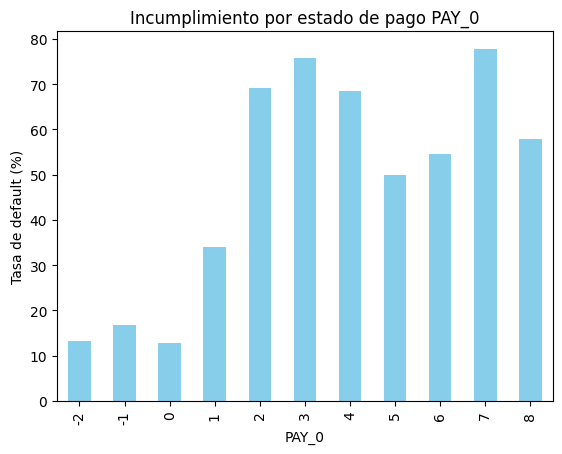

In [29]:
(100 * df.groupby("PAY_0")["default_next_month"].mean()).sort_index().plot(kind="bar", color="skyblue")
plt.ylabel("Tasa de default (%)")
plt.title("Incumplimiento por estado de pago PAY_0")
plt.show()

La tasa de incumplimiento según `PAY_0` muestra un patrón muy claro: los clientes sin atraso reciente o con categorías de pago favorables (-2, -1, 0) tienen tasas de incumplimiento relativamente bajas, entre **12.81%** y **16.78%**. En cambio, cuando aparece retraso reciente, el riesgo aumenta de forma marcada: con 1 mes de atraso la tasa sube a **33.95%**, con 2 meses alcanza **69.14%**, y con 3 meses llega a **75.78%**. Aunque en las categorías de atraso más severo hay muy pocas observaciones, el comportamiento general sugiere que PAY_0 es una de las variables más importantes del dataset para anticipar incumplimiento futuro.

### Correlación inicial entre variables numéricas

Esta exploración es preliminar y sólo busca detectar asociaciones lineales básicas.


In [30]:
cols_corr = ["LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
             "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "default_next_month"]

corr = df[cols_corr].corr() # Calculamos la matriz de correlación para las columnas seleccionadas

Para complementar la tabla de correlaciones, se construye un mapa de calor que permite visualizar de manera más clara la intensidad y dirección de la asociación lineal entre algunas variables numéricas del conjunto de datos.

En esta gráfica:

- Los valores cercanos a `1` indican correlación positiva fuerte.
- Los valores cercanos a `-1` indican correlación negativa fuerte.
- Los valores cercanos a `0` indican correlación lineal débil o nula.

Este análisis es exploratorio y permite identificar relaciones iniciales entre variables financieras, demográficas y la variable objetivo `default_next_month`.

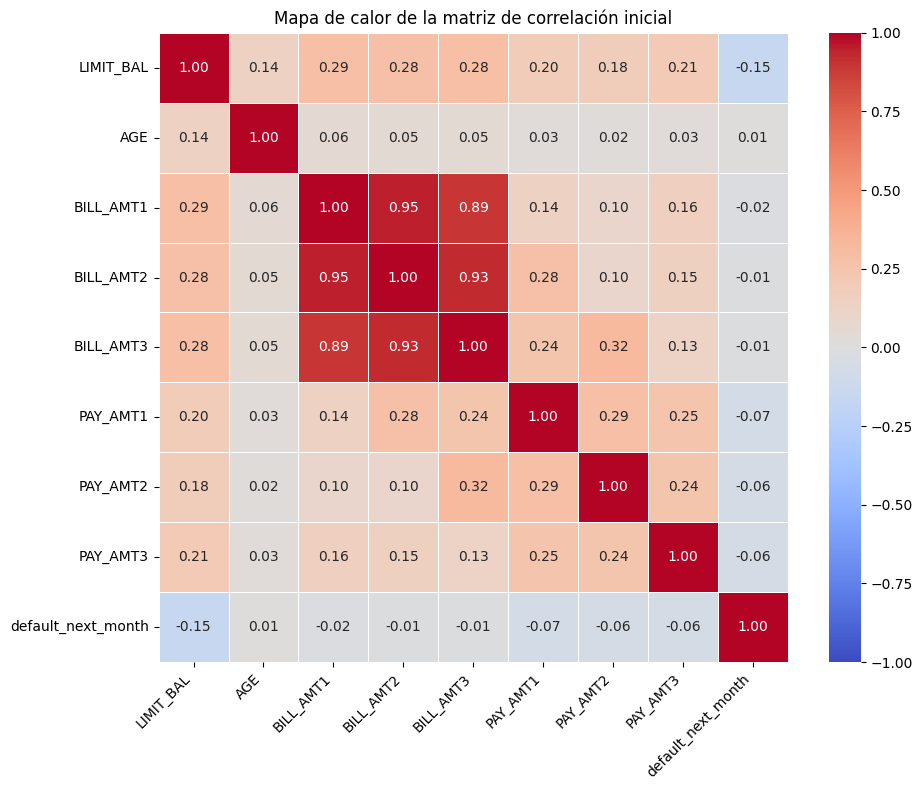

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, # Matriz de correlación a visualizar
    annot=True, # Mostrar los valores de correlación en cada celda
    fmt=".2f", # Formato de los números en las celdas (2 decimales)
    cmap="coolwarm", # Paleta de colores para el mapa de calor, donde los valores negativos se muestran en tonos fríos (azul) y los valores positivos en tonos cálidos (rojo)
    linewidths=0.5, # Ancho de las líneas que separan las celdas del mapa de calor
    square=True, # Hacer que las celdas sean cuadradas para mejor visualización
    cbar=True, # Mostrar la barra de colores que indica la escala de correlación
    vmin=-1, # Valor mínimo de correlación para la escala de colores
    vmax=1, # Valor máximo de correlación para la escala de colores
    center=0 # Centrar la escala de colores en 0 para que los valores negativos y positivos se muestren de manera equilibrada
)

plt.title("Mapa de calor de la matriz de correlación inicial")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El mapa de calor muestra que las variables de **monto facturado** (`BILL_AMT1`, `BILL_AMT2`, `BILL_AMT3`) están **fuertemente correlacionadas entre sí**, con valores entre aproximadamente **0.89** y **0.95**. Esto es razonable, ya que representan estados de cuenta de meses consecutivos y reflejan niveles de deuda similares en el tiempo.

También se observa una **correlación positiva moderada** entre `LIMIT_BAL` y las variables de facturación y pago, lo que sugiere que los clientes con mayor límite de crédito tienden a registrar montos facturados y pagos más altos. Por su parte, la variable `AGE` presenta correlaciones muy bajas con el resto, por lo que su relación lineal con estas variables parece débil.

En relación con la variable objetivo `default_next_month`, las correlaciones lineales son en general **bajas**. La asociación más visible es con `LIMIT_BAL`, que muestra una correlación negativa de aproximadamente **-0.15**, lo que sugiere que límites de crédito más altos se asocian, en promedio, con menor incumplimiento. Las variables de pago (`PAY_AMT1`, `PAY_AMT2`, `PAY_AMT3`) presentan correlaciones negativas muy pequeñas con el incumplimiento, y las variables de facturación prácticamente no muestran asociación lineal directa.

En conjunto, esta matriz sugiere dos cosas importantes: primero, existe una fuerte dependencia entre variables financieras de meses consecutivos, lo que puede implicar redundancia parcial; segundo, la variable objetivo no parece explicarse bien sólo mediante relaciones lineales simples, por lo que más adelante será importante explorar variables categóricas, historial de mora (`PAY_0`, `PAY_2`, etc.) y modelos multivariados más flexibles.